In [2]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

pb_atac_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/agg_atac_ct.h5ad")
pb_rna_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/agg_rna_ct.h5ad")    
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_100kb.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv'

In [2]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
pb_atac_ct.X = np.log10(pb_atac_ct.X * 10000000 + 1)
pb_rna_ct.X = np.log10(pb_rna_ct.X * 10000000 + 1)
print(pb_atac_ct.X)
print(pb_rna_ct.X)

[[0.59212047 0.69613707 1.17662562 ... 0.74008541 4.3662395  4.31870711]
 [0.59656407 0.81144186 1.23611758 ... 0.88886274 4.38018967 4.32868325]
 [0.63139319 0.82860369 1.15809997 ... 1.0767013  4.45318638 4.38115694]
 ...
 [0.62994205 0.9583403  1.27602498 ... 0.90292236 4.41980785 4.35557189]
 [0.61485877 0.80358501 1.24243145 ... 0.97687744 4.39997769 4.34000236]
 [0.46200484 0.78592176 1.15919359 ... 0.86188885 4.38612179 4.33702845]]
[[1.55839205 1.25530028 1.3067174  ... 4.19220295 1.01968432 0.75038734]
 [1.17715388 1.03789382 1.22591612 ... 4.21574899 1.17329388 1.10155529]
 [1.30568003 1.2243547  1.68592908 ... 4.20899791 1.18883585 0.96416806]
 ...
 [1.41729791 1.18611161 1.51347909 ... 4.192271   0.97158942 0.7858175 ]
 [1.41533918 1.29347232 1.4736311  ... 4.20691676 0.65202066 1.05776117]
 [1.17286608 1.28338185 1.30516109 ... 4.23160137 0.         0.        ]]


In [3]:
gene_peaks_100kb[0:10]

,gene_id,assigned_peaks
0,rpl24,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
1,cep97,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
2,nfkbiz,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
3,eed,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
4,hikeshi,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
5,tmem39a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
6,ildr1a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
7,gpa33a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
8,f7l,"['1-11007-12962', '1-13276-13705', '1-14059-14..."
9,f7,"['1-21199-21555', '1-21590-23611', '1-27097-29..."


In [ ]:
# OLS regression of gene expression on peak accessibility per gene
# Two-stage approach:
# 1) fit_regularized on all assigned peaks to rank/select features
# 2) refit standard OLS on the selected subset only
import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.multitest import multipletests

window_labels = ["10kb", "20kb", "50kb", "100kb"]

# ── per-window OLS result stores ──────────────────────────────────────────────
gene_peak_10kb_ols_results  = {}
gene_peak_20kb_ols_results  = {}
gene_peak_50kb_ols_results  = {}
gene_peak_100kb_ols_results = {}

ols_result_stores = {
    "10kb":  gene_peak_10kb_ols_results,
    "20kb":  gene_peak_20kb_ols_results,
    "50kb":  gene_peak_50kb_ols_results,
    "100kb": gene_peak_100kb_ols_results,
}

window_assignments_raw = {
    "10kb":  gene_peaks_10kb,
    "20kb":  gene_peaks_20kb,
    "50kb":  gene_peaks_50kb,
    "100kb": gene_peaks_100kb,
}

# ── 1. OLS loop per window → per gene ────────────────────────────────────────
for window_label, gene_peaks_df in window_assignments_raw.items():
    ols_results = ols_result_stores[window_label]

    for gene_id in gene_peaks_df["gene_id"]:
        # ── retrieve & parse assigned peaks ───────────────────────────────────
        assigned_peaks_raw = gene_peaks_df.loc[
            gene_peaks_df["gene_id"] == gene_id, "assigned_peaks"
        ].iloc[0]

        if isinstance(assigned_peaks_raw, str):
            assigned_peaks = ast.literal_eval(assigned_peaks_raw)
        else:
            assigned_peaks = assigned_peaks_raw

        # keep only peaks present in ATAC object
        assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct.var_names]

        peak_ols = {}
        if len(assigned_peaks) == 0:
            ols_results[gene_id] = peak_ols
            continue

        # ── response variable: gene expression (y) ────────────────────────────
        y = np.asarray(pb_rna_ct[:, gene_id].X).ravel().astype(float)

        # skip gene if expression is constant or sample size is too small
        if np.std(y) == 0 or y.shape[0] < 2:
            ols_results[gene_id] = peak_ols
            continue

        # ── predictor matrix: accessibility for all assigned peaks ────────────
        X_raw = np.asarray(pb_atac_ct[:, assigned_peaks].X).astype(float)
        n_samples = X_raw.shape[0]
        n_peaks_total = X_raw.shape[1]

        # select at most n_samples - 2 peaks, to fit a model with intercept and avoid perfect fit issues
        n_select = max(1, min(n_peaks_total, n_samples - 2))

        # stage 1: regularized fit for feature ranking, with fallback to correlation ranking if it fails
        X_full = add_constant(X_raw, prepend=True)
        try:
            reg_result = OLS(y, X_full).fit_regularized(alpha=0.5, L1_wt=0.5)
            reg_params = np.asarray(reg_result.params)
        except Exception:
            # fallback: rank by simple correlation with y if regularized fit fails
            reg_params = np.zeros(n_peaks_total + 1, dtype=float)
            for idx in range(n_peaks_total):
                x_col = X_raw[:, idx]
                if np.std(x_col) == 0:
                    reg_params[idx + 1] = 0.0
                else:
                    corr = np.corrcoef(x_col, y)[0, 1]
                    reg_params[idx + 1] = 0.0 if np.isnan(corr) else corr

        # rank by the regularized coefficients themselves (excluding intercept)
        peak_scores = np.abs(reg_params[1:])
        ranked_peak_indices = np.argsort(peak_scores)[::-1]
        selected_peak_indices = ranked_peak_indices[:n_select]
        selected_peak_indices = np.sort(selected_peak_indices)
        selected_peaks = [assigned_peaks[idx] for idx in selected_peak_indices]

        # stage 2: refit standard OLS on the selected peaks only
        X_selected = X_raw[:, selected_peak_indices]
        X = add_constant(X_selected, prepend=True)
        model = OLS(y, X)
        result = model.fit()
        conf_int = result.conf_int()

        peak_ols["selection"] = {
            "n_samples": n_samples,
            "n_peaks_total": n_peaks_total,
            "n_selected": len(selected_peaks),
            "selected_peaks": selected_peaks,
            "regularized_params": reg_params.tolist(),
        }

        peak_ols["model"] = {
            "intercept": result.params[0],
            "r_squared": result.rsquared,
            "adj_r_squared": result.rsquared_adj,
            "f_statistic": result.fvalue,
            "f_pval": result.f_pvalue,
            "aic": result.aic,
            "bic": result.bic,
            "padj": np.nan,
        }

        for peak_idx, peak_id in enumerate(selected_peaks):
            param_idx = peak_idx + 1  # +1 because index 0 is intercept
            peak_ols[peak_id] = {
                "coef": result.params[param_idx],
                "std_err": result.bse[param_idx],
                "t_stat": result.tvalues[param_idx],
                "pval": result.pvalues[param_idx],
                "conf_int_lower": conf_int[param_idx, 0],
                "conf_int_upper": conf_int[param_idx, 1],
                "padj": np.nan,
            }

        ols_results[gene_id] = peak_ols

    print(f"[{window_label}] Two-stage OLS complete — {len(ols_results)} genes processed")



# ── 3. Build tidy summary DataFrame ──────────────────────────────────────────
all_ols_results = []

for window_label, ols_results in ols_result_stores.items():
    for gene_id, peak_ols in ols_results.items():
        for peak_id, stats in peak_ols.items():
            if peak_id in {"model", "selection"}:
                continue
            if not isinstance(stats, dict):
                continue

            pval = stats.get("pval", np.nan)
            padj = stats.get("padj", np.nan)

            if np.isfinite(pval) and 0 < pval <= 1:
                all_ols_results.append({
                    "window": window_label,
                    "gene": gene_id,
                    "peak": peak_id,
                    "coef": stats.get("coef", np.nan),
                    "std_err": stats.get("std_err", np.nan),
                    "t_stat": stats.get("t_stat", np.nan),
                    "conf_int_lower": stats.get("conf_int_lower", np.nan),
                    "conf_int_upper": stats.get("conf_int_upper", np.nan),
                    "pval": pval,
                    "neglog10_pval": -np.log10(pval),
                    "padj": padj,
                    "neglog10_padj": -np.log10(padj) if np.isfinite(padj) and padj > 0 else np.nan,
                })

ols_res_df = pd.DataFrame(all_ols_results)

ols_res_df["window"] = pd.Categorical(
    ols_res_df["window"],
    categories=window_labels,
    ordered=True,
)

print(f"\nOLS summary DataFrame: {ols_res_df.shape[0]:,} peak–gene pairs")
print(ols_res_df.head())



[10kb] Two-stage OLS complete — 19380 genes processed
[20kb] Two-stage OLS complete — 19380 genes processed
[50kb] Two-stage OLS complete — 19380 genes processed
[100kb] Two-stage OLS complete — 19380 genes processed

OLS summary DataFrame: 1,941,335 peak–gene pairs
  window   gene           peak      coef   std_err    t_stat  conf_int_lower  \
0   10kb  rpl24    1-2372-3057 -0.005681  0.043840 -0.129589       -0.095970   
1   10kb  rpl24    1-3427-4032 -0.085036  0.046254 -1.838470       -0.180298   
2   10kb  rpl24    1-4469-7268  0.103293  0.102764  1.005141       -0.108354   
3   10kb  rpl24    1-9541-9969 -0.044290  0.075234 -0.588697       -0.199238   
4   10kb  rpl24  1-11007-12962 -0.087808  0.155427 -0.564949       -0.407916   

   conf_int_upper      pval  neglog10_pval  padj  neglog10_padj  
0        0.084608  0.897929       0.046758   NaN            NaN  
1        0.010225  0.077903       1.108443   NaN            NaN  
2        0.314940  0.324459       0.488840   NaN      

In [4]:
#save results
#ols_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_ols_ct_results.csv", index=False)

#read results
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_ols_ct_results.csv.gz")    

/tmp/ipykernel_53534/3636771642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='window', ylabel='neglog10_pval'>

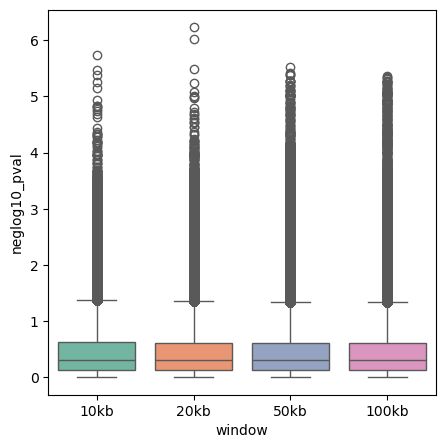

In [5]:
#plot the distribution of the pvalues for all windows
import matplotlib.pyplot as plt
import seaborn as sns   
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    data=ols_res_df.dropna(subset=["pval"]),
    x="window",
    y="neglog10_pval",
    palette="Set2",
    ax=ax,
)

In [10]:
#count the na
ols_res_df["pval_na"] = ols_res_df["pval"].isna()
pval_na_counts = ols_res_df.groupby("window").size().reset_index(name="pval_na_count")
print("\nCount of peaks per window:")
print(pval_na_counts)   




Count of peaks per window:
  window  pval_na_count
0  100kb         706828
1   10kb         172007
2   20kb         360340
3   50kb         702160


In [11]:
# classify every peak–gene pair into one of three categories and count how many pairs fall into each category per window and gene
def classify_pair(row):
    if row["pval"] <= 0.05 and row["coef"] < 0:
        return "sig. negative"
    elif row["pval"] <= 0.05 and row["coef"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

ols_res_df["category"] = ols_res_df.apply(classify_pair, axis=1)
print(ols_res_df.head())

agg_ols_res_df = (
    ols_res_df
    .dropna(subset=["coef", "pval", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

agg_ols_res_df.head()


  window   gene           peak      coef   std_err    t_stat  conf_int_lower  \
0   10kb  rpl24    1-2372-3057 -0.005681  0.043840 -0.129589       -0.095970   
1   10kb  rpl24    1-3427-4032 -0.085036  0.046254 -1.838470       -0.180298   
2   10kb  rpl24    1-4469-7268  0.103293  0.102764  1.005141       -0.108354   
3   10kb  rpl24    1-9541-9969 -0.044290  0.075234 -0.588697       -0.199238   
4   10kb  rpl24  1-11007-12962 -0.087808  0.155427 -0.564949       -0.407916   

   conf_int_upper      pval  neglog10_pval  padj  neglog10_padj  pval_na  \
0        0.084608  0.897929       0.046758   NaN            NaN    False   
1        0.010225  0.077903       1.108443   NaN            NaN    False   
2        0.314940  0.324459       0.488840   NaN            NaN    False   
3        0.110658  0.561347       0.250769   NaN            NaN    False   
4        0.232299  0.577143       0.238716   NaN            NaN    False   

          category  
0  non-significant  
1  non-significant  

,window,gene,category,count
0,100kb,a1cf,non-significant,37
1,100kb,a2ml,non-significant,37
2,100kb,aaas,non-significant,37
3,100kb,aacs,non-significant,37
4,100kb,aadac,non-significant,37


In [12]:
agg_ols_res_df.groupby(["window","category"])["count"].sum()
agg_ols_res_df.shape    

(106974, 4)

In [39]:
#read in the aggregated results from correlation analysis
agg_cor_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/agg_cor_df_ct.csv")

In [40]:
#merge the two aggregated dataframes on window, gene 

#rename the count column in agg_cor_df to count_cor to avoid confusion with the count column in agg_ols_res_df
agg_cor_df["count_cor"] = agg_cor_df['count']
agg_ols_res_df["count_ols"] = agg_ols_res_df['count']

agg_merged_df = pd.merge(
    agg_cor_df,
    agg_ols_res_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

,window,gene,category,count_x,count_cor,count_y,count_ols
0,100kb,a1cf,non-significant,NaN,NaN,37.0,37.0
1,100kb,a1cf,sig. positive,8.0,8.0,NaN,NaN
2,100kb,a2ml,non-significant,NaN,NaN,37.0,37.0
3,100kb,a2ml,sig. negative,1.0,1.0,NaN,NaN
4,100kb,a2ml,sig. positive,3.0,3.0,NaN,NaN


In [15]:
# count occurences of (count_cor and count_ols) per window
plotdf = agg_merged_df.groupby(["window","count_cor","count_ols"]).size().reset_index(name="counts")

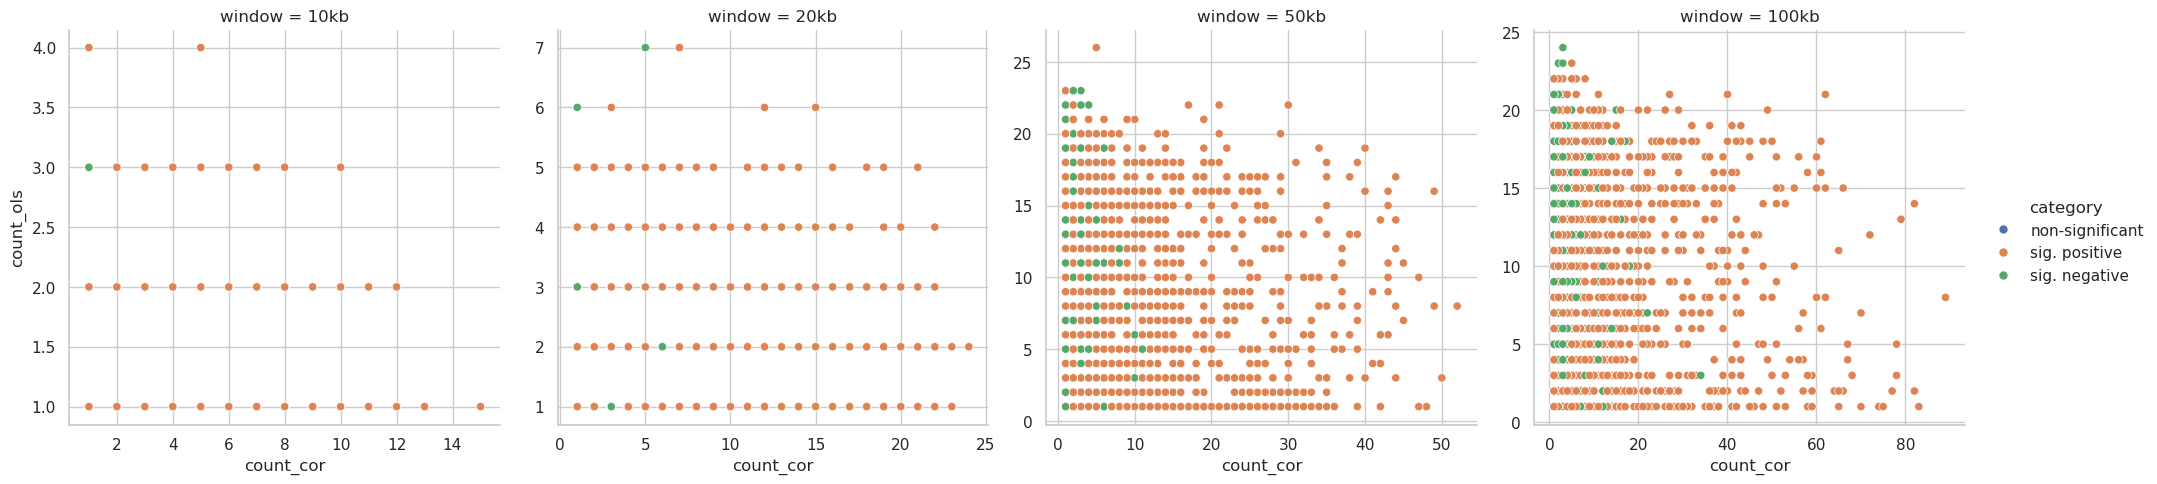

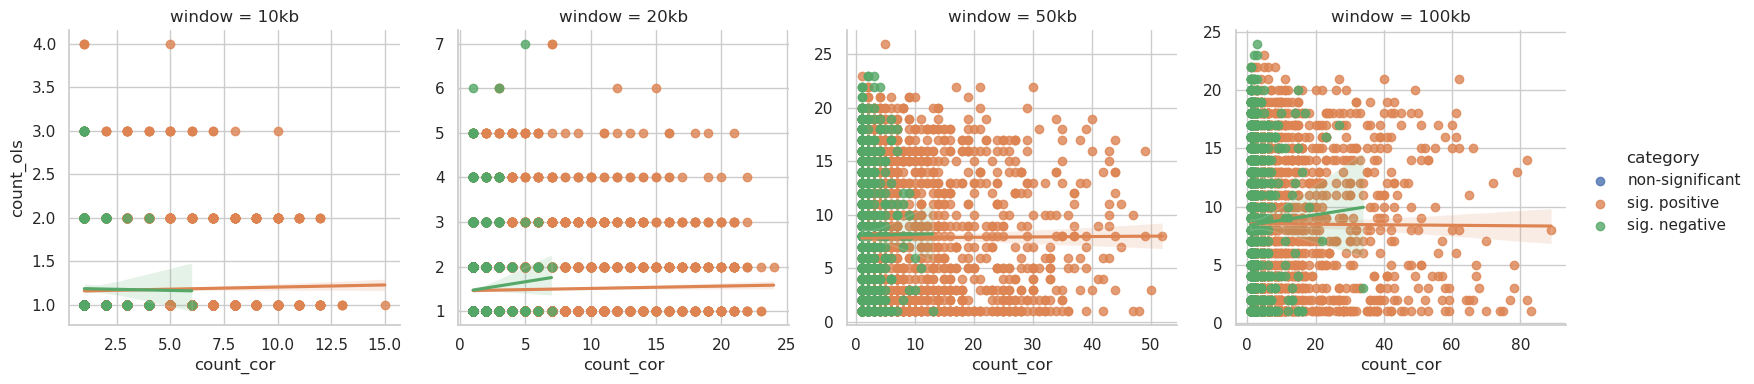

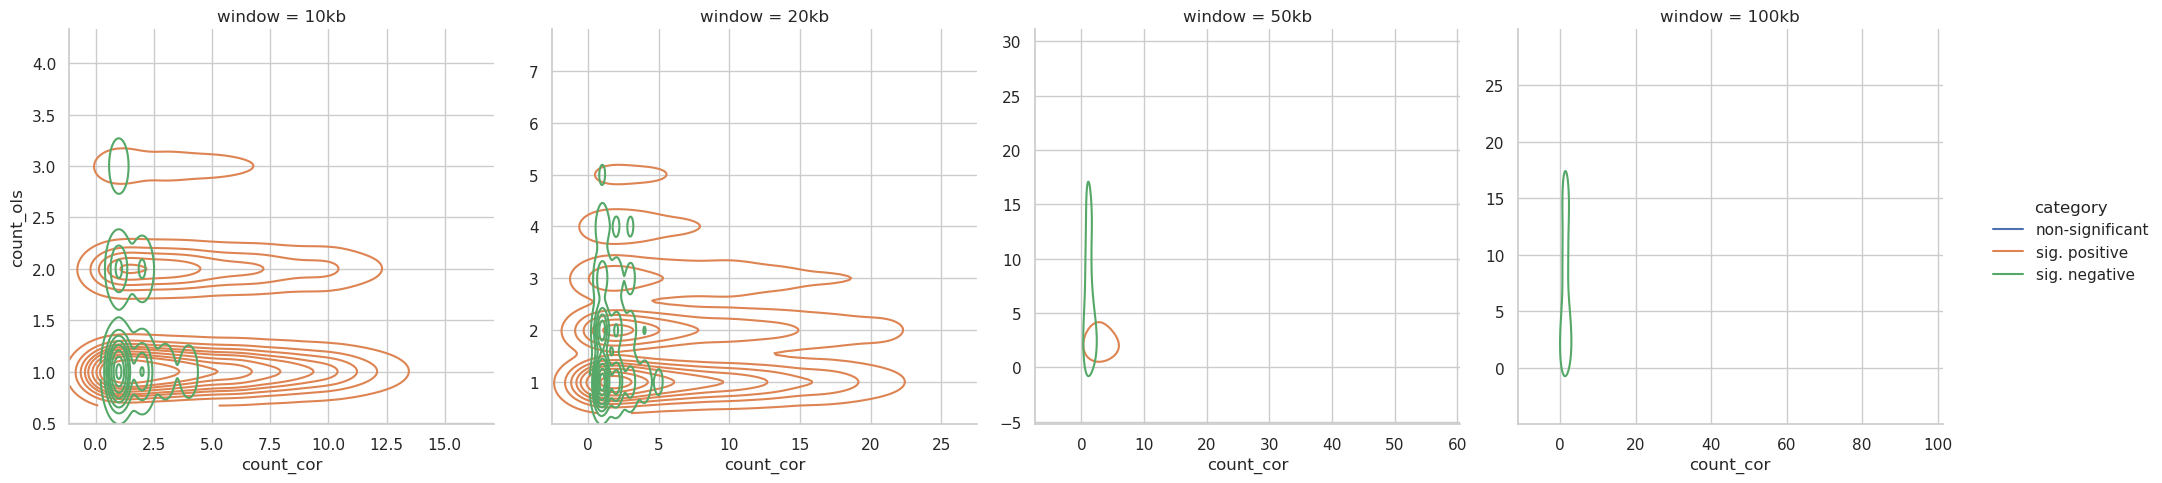

In [19]:
#scatterplot of count_cor vs. count_ols faceted by window and colored by category
import seaborn as sns
import matplotlib.pyplot as plt 
sns.set(style="whitegrid")

window_labels = ["10kb", "20kb", "50kb", "100kb"]

sns.relplot(
    data=agg_merged_df,
    x="count_cor",
    y="count_ols",
    hue="category",
    col="window",
    kind="scatter",
    col_order=window_labels,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

sns.lmplot(
    data=agg_merged_df,
    x="count_cor",
    y="count_ols",
    hue="category",
    col="window",
    aspect=1,
    height=4,
    col_order=window_labels,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

#density plot of count_cor vs. count_ols faceted by window and colored by category
sns.displot(
    data=agg_merged_df,
    x="count_cor",
    y="count_ols",
    hue="category",
    col="window",
    kind="kde",
    col_order=window_labels,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

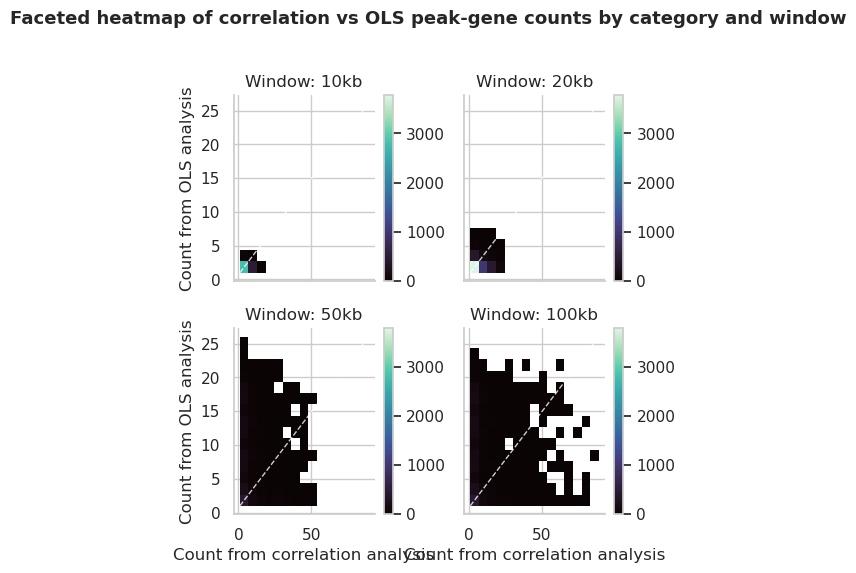

In [20]:
# Faceted 2D histogram heatmap of count_cor vs. count_ols by window and category
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid", context="notebook")

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

# Faceted heatmap-like plot using a 2D histogram
# columns = 2 rows
h = sns.displot(
    data=plot_df,
    x="count_cor",
    y="count_ols",
    col="window",
    col_wrap=2,
    col_order=["10kb", "20kb", "50kb", "100kb"],
    kind="hist",
    bins=15,
    cbar=True,
    cmap="mako",
    facet_kws={"sharex": True, "sharey": True},
    height=2.8,
    aspect=0.95,
)

x_min = plot_df["count_cor"].min()
x_max = plot_df["count_cor"].max()
y_min = plot_df["count_ols"].min()
y_max = plot_df["count_ols"].max()

for ax in h.axes.flat:
    ax.plot(
        [x_min, x_max],
        [y_min, y_max],
        linestyle="--",
        color="white",
        linewidth=1.0,
        alpha=0.8,
    )
    ax.set_xlabel("Count from correlation analysis")
    ax.set_ylabel("Count from OLS analysis")

h.set_titles(row_template="Category: {row_name}", col_template="Window: {col_name}")
h.figure.suptitle(
    "Faceted heatmap of correlation vs OLS peak-gene counts by category and window",
    y=1.02,
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

In [21]:
agg_ols_res_df
print(agg_ols_res_df[agg_ols_res_df['category'] != "non-significant"].groupby(["window","category"])["count"].sum())
print(agg_ols_res_df[agg_ols_res_df['category'] != "non-significant"].groupby(["window","category"])["count"].mean())
print(agg_ols_res_df[agg_ols_res_df['category'] != "non-significant"].groupby(["window","category"])["count"].max())
print(agg_ols_res_df[agg_ols_res_df['category'] != "non-significant"].groupby(["window","category"])["count"].min())

window  category     
100kb   sig. negative    18213
        sig. positive    18214
10kb    sig. negative     4997
        sig. positive     4927
20kb    sig. negative     9968
        sig. positive     9731
50kb    sig. negative    17855
        sig. positive    17741
Name: count, dtype: int64
window  category     
100kb   sig. negative    8.431944
        sig. positive    8.455896
10kb    sig. negative    1.177704
        sig. positive    1.170587
20kb    sig. negative    1.495574
        sig. positive    1.479100
50kb    sig. negative    7.858715
        sig. positive    7.853475
Name: count, dtype: float64
window  category     
100kb   sig. negative    24
        sig. positive    25
10kb    sig. negative     5
        sig. positive     4
20kb    sig. negative     8
        sig. positive     7
50kb    sig. negative    23
        sig. positive    26
Name: count, dtype: int64
window  category     
100kb   sig. negative    1
        sig. positive    1
10kb    sig. negative    1
       

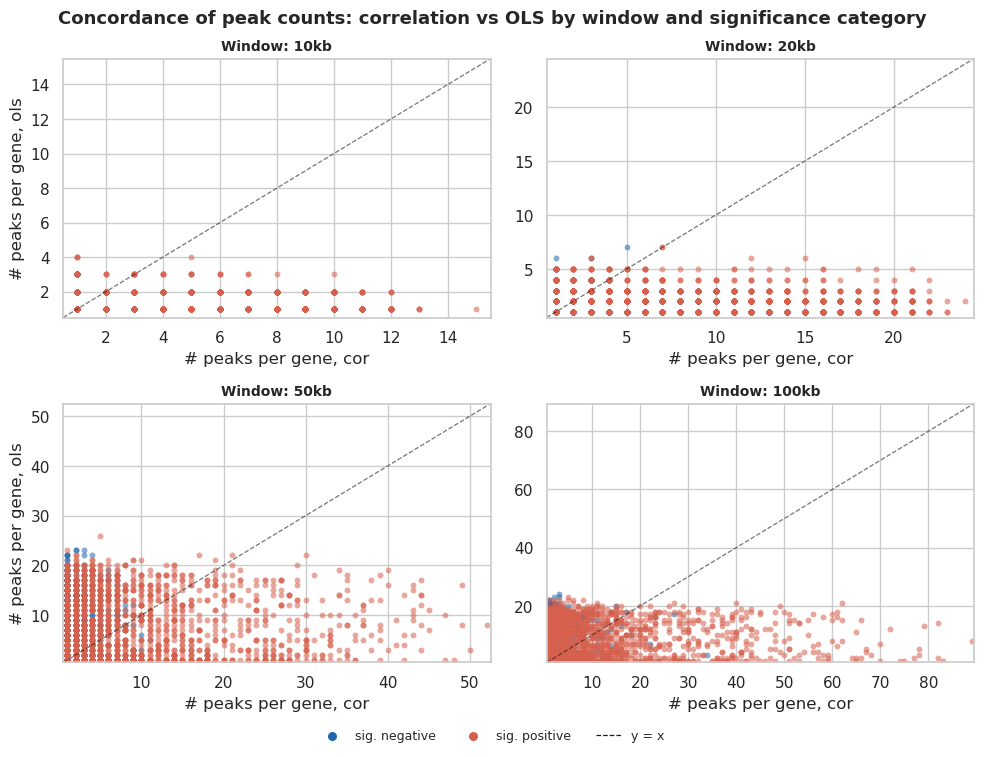

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"]

category_palette = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
axes = axes.flatten()

for col_idx, win in enumerate(windows):
    sub = plot_df_non[plot_df_non["window"] == win]
    ax = axes[col_idx]

    for cat in category_order:
        d = sub[sub["category"] == cat]
        ax.scatter(
            d["count_cor"],
            d["count_ols"],
            c=category_palette[cat],
            label=cat,
            alpha=0.55,
            s=18,
            linewidths=0,
        )

    if not sub.empty:
        lim = [
            sub[["count_cor", "count_ols"]].min().min() - 0.5,
            sub[["count_cor", "count_ols"]].max().max() + 0.5,
        ]
        ax.plot(lim, lim, "k--", lw=0.9, alpha=0.6, label="y = x")
        ax.set_xlim(lim)
        ax.set_ylim(lim)

    ax.set_title(f"Window: {win}", fontweight="bold", fontsize=10)
    ax.set_xlabel("# peaks per gene, cor")
    ax.set_ylabel("# peaks per gene, ols" if col_idx % 2 == 0 else "")

# Shared legend
handles = [
    plt.scatter([], [], c=category_palette[c], s=30, label=c)
    for c in category_order
]
handles.append(plt.Line2D([0], [0], color="k", ls="--", lw=0.9, label="y = x"))
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.02),
    frameon=False,
    fontsize=9,
 )

fig.suptitle(
    "Concordance of peak counts: correlation vs OLS by window and significance category",
    fontsize=13,
    fontweight="bold",
    y=0.95,
 )

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

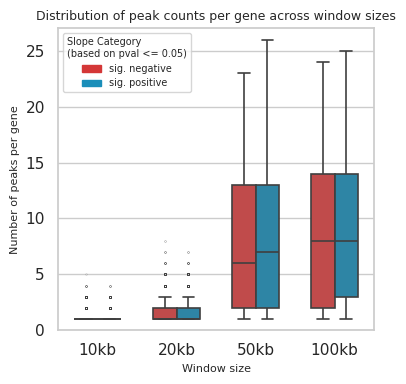

In [23]:
# Plot boxplot for each window colored by category (excluding non-significant)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}

# Start from agg_ols_res_df and remove non-significant category
plot_df = agg_ols_res_df[agg_ols_res_df["category"] != "non-significant"].copy()
plot_df = plot_df.dropna(subset=["count"])
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=window_labels,
    ordered=True,
)



fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    data=plot_df,
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    showfliers=True,
     flierprops={
        "marker": ".",
        "markersize": 2.5,
        "alpha": 0.5,
        "markeredgewidth": 0.2,
    },
    ax=ax,
 )

#scale the yaxis to the maximum outlier value across all windows
y_max = plot_df["count"].max()
ax.set_ylim(0, y_max + 1)
ax.set_xlabel("Window size", fontsize=8)
ax.set_ylabel("Number of peaks per gene", fontsize=8)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=9)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on pval <= 0.05)",
    fontsize=7,
    title_fontsize=7,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
plt.show()


In [36]:
#saving the ols results as csv
plot_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/ols_peak_count_summary.csv", index=False)


In [37]:

print(plot_df.groupby("window").size())
print(plot_df.groupby(["window","category"])["count"].agg(["count","min","max"]))

print(plot_df["window"].unique())

window
10kb      8452
20kb     13244
50kb      4531
100kb     4314
dtype: int64
                      count  min  max
window category                      
10kb   sig. negative   4243    1    5
       sig. positive   4209    1    4
20kb   sig. negative   6665    1    8
       sig. positive   6579    1    7
50kb   sig. negative   2272    1   23
       sig. positive   2259    1   26
100kb  sig. negative   2160    1   24
       sig. positive   2154    1   25
['100kb', '10kb', '20kb', '50kb']
Categories (4, object): ['10kb' < '20kb' < '50kb' < '100kb']


/tmp/ipykernel_53534/2900682210.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df.groupby("window").size())
/tmp/ipykernel_53534/2900682210.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df.groupby(["window","category"])["count"].agg(["count","min","max"]))


In [44]:
plot_df.head()

,window,gene,category,count,count_ols
6,100kb,aadacl4,sig. positive,1,1
42,100kb,abcb7,sig. negative,10,10
43,100kb,abcb7,sig. positive,12,12
50,100kb,abcc13,sig. negative,3,3
51,100kb,abcc13,sig. positive,1,1


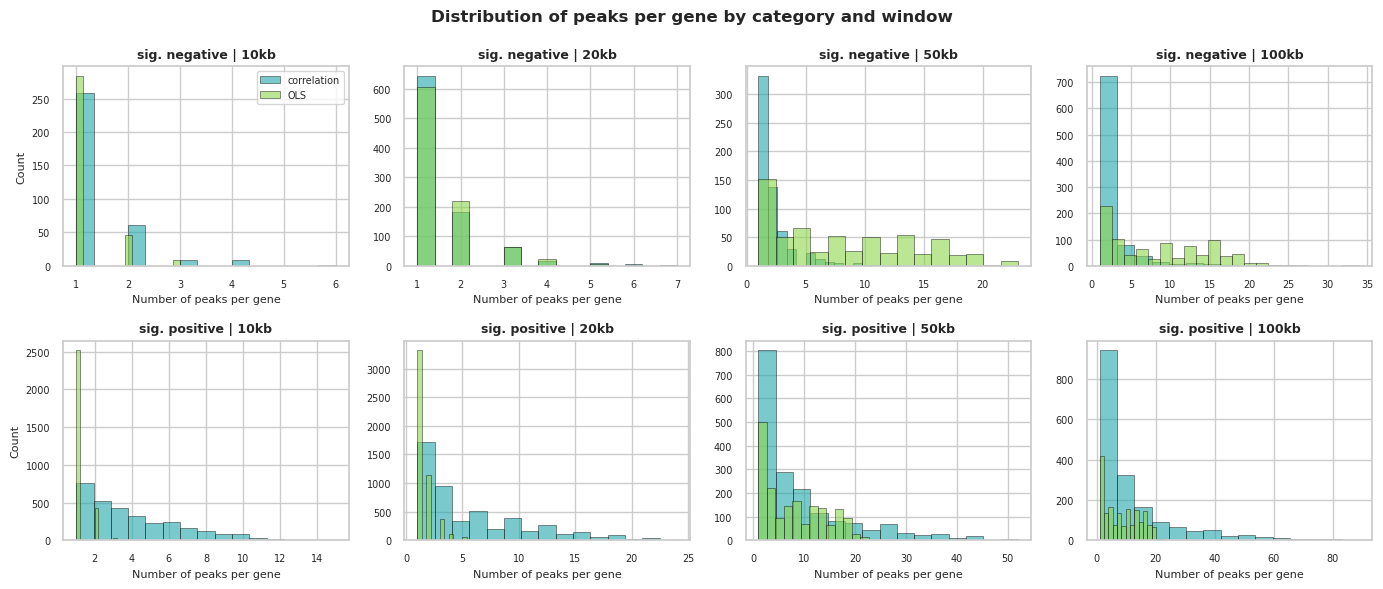

In [50]:
plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#21a7ac", "OLS": "#8fd64d"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]
    
    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]
        
        # Plot correlation histogram
        ax.hist(win_data["count_cor"], bins=15, alpha=0.6, label="correlation", color=method_colors["correlation"], edgecolor="black", linewidth=0.5)
        # Plot OLS histogram
        ax.hist(win_data["count_ols"], bins=15, alpha=0.6, label="OLS", color=method_colors["OLS"], edgecolor="black", linewidth=0.5)
        
        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)
        
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()